<a href="https://colab.research.google.com/github/Mukundan-T/seqADAGE/blob/master/Py/muk_transfer_learning/filtering/Mukundan_sa_filt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# S. aureus - Filtering

### By: Mukundan Thanigaivelan

#### July 9, 2026

In this notebook, we filter S. aureus genes and samples to roughly obtain a normal distribution of our gene expression for inputting into the Denoising AutoEncoder (DAE).

The data have already been log-transformed and 0-1 scaled.

## 1. Connect to GitHub

In [1]:
!git clone https://github.com/Mukundan-T/seqADAGE.git

Cloning into 'seqADAGE'...
remote: Enumerating objects: 633, done.
remote: Counting objects: 100% (107/107), done.
remote: Compressing objects: 100% (75/75), done.
remote: Total 633 (delta 76), reused 32 (delta 32), pack-reused 526 (from 2)
Receiving objects: 100% (633/633), 52.98 MiB | 17.15 MiB/s, done.
Resolving deltas: 100% (326/326), done.


In [2]:
%cd seqADAGE/Py/muk_transfer_learning/filtering

/content/seqADAGE/Py/muk_transfer_learning/filtering


In [3]:
!pip install -qq seaborn pydeseq2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 115.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 137.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 162.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.6/87.6 kB 8.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is th

## 2. Loading classes & modules

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

In [6]:
# Data Analysis
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Miscellaneous
import time
import re
import tensorflow as tf
from pydeseq2.preprocessing import deseq2_norm

In [7]:
# check CPU and GPU available in runtime
print("Num CPUs Available: ", len(tf.config.list_physical_devices('CPU')))
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print(tf.test.is_built_with_cuda())

Num CPUs Available:  1
Num GPUs Available:  1
True


## 3. Data filtering

Here we are looking at S. aureus genes, with expression that has been log transformed and scaled to be between 0 and 1.

### Preparation

In [337]:
all_comp = pd.read_csv('/content/drive/My Drive/Comp-Bio-Projs-S26/data/muk-in-use/sapg_lcn01.csv', index_col = 0)
gene_num = np.size(all_comp, 0)
samp_num = np.size(all_comp, 1)

In [338]:
print(f"There are {gene_num} genes (features) and {samp_num} samples")

There are 8961 genes (features) and 3737 samples


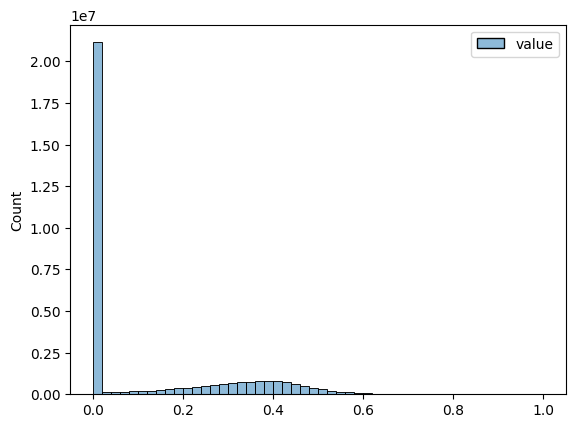

In [339]:
fig = sns.histplot(pd.melt(all_comp), bins = 50)

### Gene-wise Filtering

In [340]:
# Get gene sample statistics
gene_stats = all_comp.T.describe().T
gene_stats.head()

,count,mean,std,min,25%,50%,75%,max
12b493b74dec297122c11824ed05ba01_1000,3737.0,0.488977,0.026861,0.368983,0.473390,0.489876,0.504804,0.611240
12b493b74dec297122c11824ed05ba01_1002,3737.0,0.549838,0.059249,0.227893,0.516761,0.551270,0.586811,0.939061
12b493b74dec297122c11824ed05ba01_1004,3737.0,0.363523,0.034345,0.000000,0.344430,0.363432,0.384248,0.503254
12b493b74dec297122c11824ed05ba01_1006,3737.0,0.462550,0.031850,0.318882,0.442544,0.462511,0.481403,0.609086
12b493b74dec297122c11824ed05ba01_1008,3737.0,0.421639,0.030869,0.324687,0.403107,0.421128,0.438587,0.568538


Text(0.5, 1.0, 'Mean vs. 75th percentile expression')

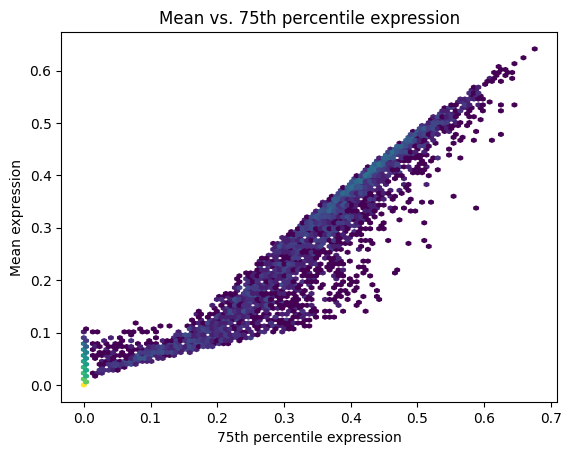

In [341]:
# Preliminary hexagonal binning log-scaled plot of 75th percentile versus mean
plt.hexbin(
  x = gene_stats['75%'],
  y = gene_stats['mean'],
  bins = 'log'
)

plt.xlabel("75th percentile expression")
plt.ylabel("Mean expression")
plt.title("Mean vs. 75th percentile expression")

In [342]:
# Empirically determined constant for threshold
c = 0.06

# Cutoff lines to filter genes
x1 = np.linspace(0.1, 0.7, 200)
x2 = np.linspace(0, 0.7, 200)

y1 = x1 - c
y2 = x2

Text(0.5, 1.0, 'Mean vs. 75th percentile expression')

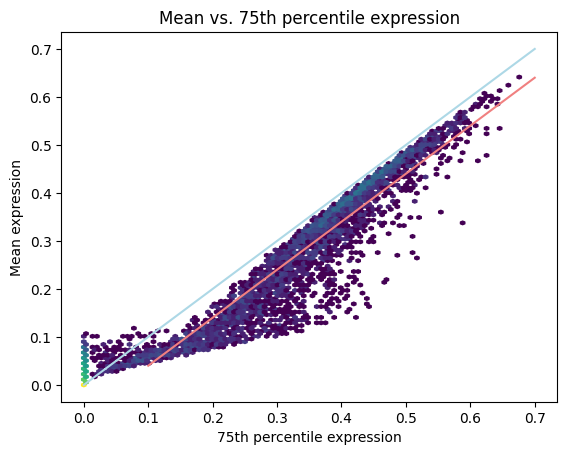

In [343]:
# Plot with threshold lines for filtering out genes
plt.hexbin(
  x = gene_stats['75%'],
  y = gene_stats['mean'],
  bins = 'log'
)

plt.plot(x1, y1, color = 'lightcoral')
plt.plot(x2, y2, color = 'lightblue')

plt.xlabel("75th percentile expression")
plt.ylabel("Mean expression")
plt.title("Mean vs. 75th percentile expression")

In [344]:
# Set thresholds to remove genes
threshold1 = gene_stats['75%'] - c # red
threshold2 = gene_stats['75%'] # blue

# Genes to remove
genes_to_rm = gene_stats[
  (gene_stats['mean'] < threshold1) |
  (gene_stats['mean'] > threshold2)
]
genes_to_rm.shape

(6831, 8)

In [345]:
# Remove the genes
filtered_genes = all_comp.drop(index = genes_to_rm.index)
filtered_genes.shape

(2130, 3737)

In [346]:
# Get filtered gene stats
filtered_stats = filtered_genes.T.describe().T

Text(0.5, 1.0, 'Mean vs. 75th percentile expression')

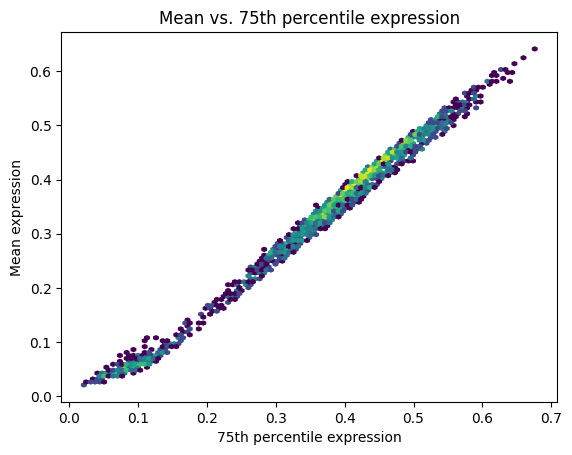

In [347]:
# Plot of gene expression 75th percentile versus mean after filtering
plt.hexbin(
  x = filtered_stats['75%'],
  y = filtered_stats['mean'],
  bins = 'log'
)
plt.xlabel("75th percentile expression")
plt.ylabel("Mean expression")
plt.title("Mean vs. 75th percentile expression")

<Axes: ylabel='Count'>

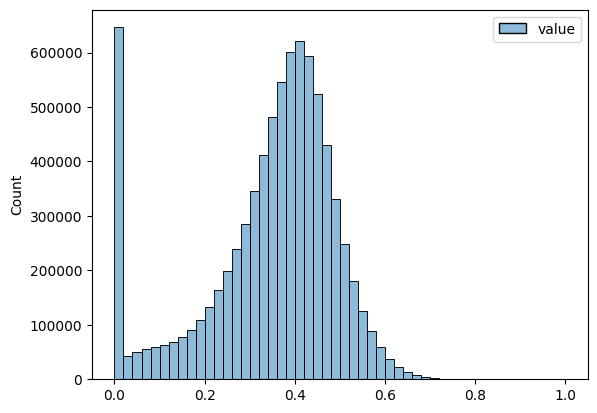

In [348]:
# Histogram of gene expression - getting better but needs work
sns.histplot(pd.melt(filtered_genes), bins=50)

### Experiment-wise Filtering

In [349]:
# Get experiment sample statistics
exp_stats = filtered_genes.describe().T
exp_stats.head()

,count,mean,std,min,25%,50%,75%,max
DRX011556,2130.0,0.343910,0.148876,0.0,0.285134,0.372168,0.437286,0.707659
DRX011557,2130.0,0.348326,0.145914,0.0,0.291743,0.374053,0.439914,0.712363
DRX011558,2130.0,0.347437,0.149090,0.0,0.289805,0.373924,0.440714,0.716095
DRX011559,2130.0,0.347289,0.152039,0.0,0.294714,0.380308,0.446768,0.694309
DRX011560,2130.0,0.337225,0.160642,0.0,0.285400,0.375817,0.443686,0.687590


Text(0.5, 1.0, 'Median vs. mean expression')

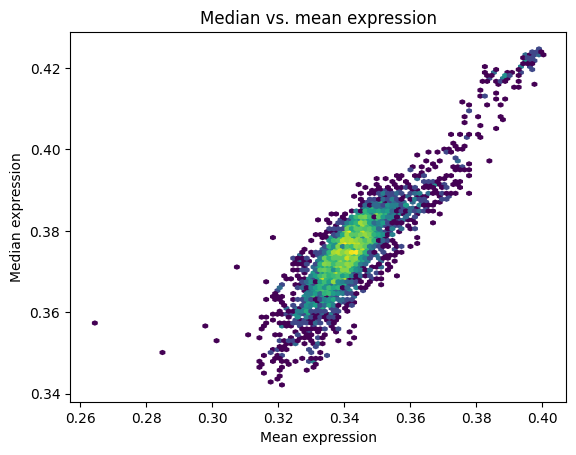

In [350]:
# Preliminary hexagonal binning log-scaled plot of median versus mean
plt.hexbin(
  x = exp_stats['mean'],
  y = exp_stats['50%'],
  bins = 'log'
)

plt.xlabel("Mean expression")
plt.ylabel("Median expression")
plt.title("Median vs. mean expression")

In [351]:
# Empirically determined constant for threshold
c = 0.02

# Cutoff lines to filter samples
x = np.linspace(0.32, 0.40, 200)
y = x + c

Text(0.5, 1.0, 'Median vs. mean expression')

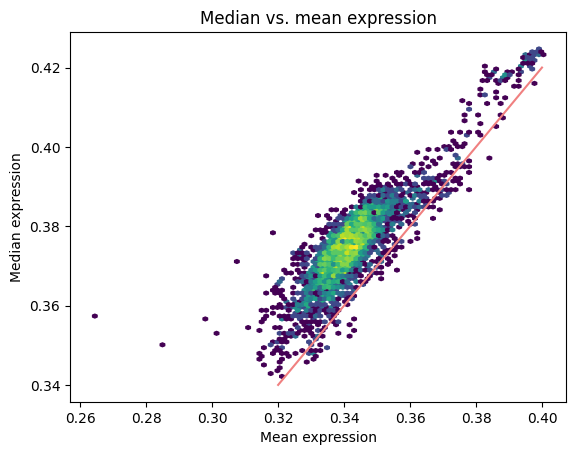

In [352]:
# Plot with threshold lines for filtering out samples
plt.hexbin(
  x = exp_stats['mean'],
  y = exp_stats['50%'],
  bins = 'log'
)

plt.plot(x, y, color = 'lightcoral')

plt.xlabel("Mean expression")
plt.ylabel("Median expression")
plt.title("Median vs. mean expression")

In [353]:
# Set thresholds to remove samples
threshold1 = exp_stats['mean'] + c

# Samples to remove
exps_to_rm = exp_stats[exp_stats['50%'] > threshold1]
exps_to_rm.shape

(3639, 8)

In [354]:
# Remove the samples
filtered_df = filtered_genes.drop(columns = exps_to_rm.index)
filtered_df.shape

(2130, 98)

In [355]:
# Get filtered stats
final_stats = filtered_df.describe().T

Text(0.5, 1.0, 'Median vs. mean expression')

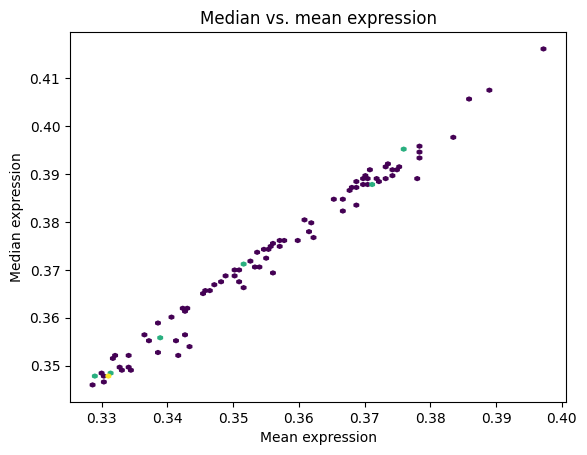

In [356]:
# Plot of sample expression median versus mean after filtering
plt.hexbin(
  x = final_stats['mean'],
  y = final_stats['50%'],
  bins = 'log'
)
plt.xlabel("Mean expression")
plt.ylabel("Median expression")
plt.title("Median vs. mean expression")

<Axes: ylabel='Count'>

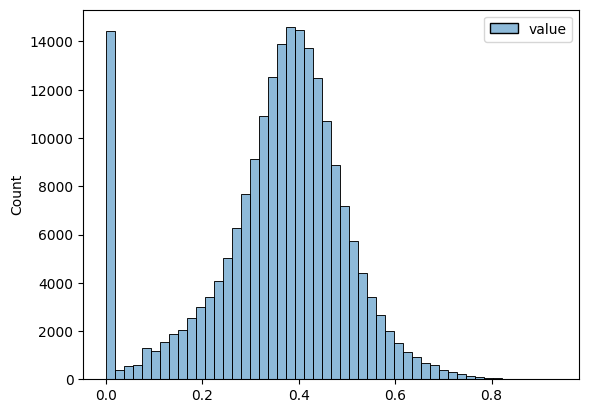

In [357]:
# Histogram of gene expression - somewhat normal, but severely zero-inflated
# due to the nature of the data
sns.histplot(pd.melt(filtered_df), bins=50)

### Final Filtered Data

In [358]:
# Size of filtered genes and samples
filtered_df.shape

(2130, 98)